In [ ]:
import sys
sys.path.append("Normalized-Attention-Guidance")
import torch

from nag import NAGStableDiffusion3Pipeline, NAGSD3Transformer2DModel

model_id = "stabilityai/stable-diffusion-3.5-large-turbo"

model = NAGSD3Transformer2DModel.from_pretrained(model_id,
                                                 subfolder="transformer",
                                                 torch_dtype=torch.bfloat16)

pipe = NAGStableDiffusion3Pipeline.from_pretrained(
    model_id,
    transformer=model,
    torch_dtype=torch.bfloat16,
)
pipe = pipe.to("cuda:1")

/home/wg25r/miniconda/envs/neg/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 9/9 [00:02<00:00,  3.19it/s]


In [ ]:
# from hpsv3 import HPSv3RewardInferencer
# # Initialize the model
# inferencer = HPSv3RewardInferencer(device='cuda:2')

In [ ]:
import numpy as np
from PIL import Image

def vstack(images):
    if len(images) == 0:
        raise ValueError("Need 0 or more images")

    if isinstance(images[0], np.ndarray):
        images = [Image.fromarray(img) for img in images]
    width = max([img.size[0] for img in images])
    height = sum([img.size[1] for img in images])
    stacked = Image.new(images[0].mode, (width, height))

    y_pos = 0
    for img in images:
        stacked.paste(img, (0, y_pos))
        y_pos += img.size[1]
    return stacked


def hstack(images):
    if len(images) == 0:
        raise ValueError("Need 0 or more images")

    if isinstance(images[0], np.ndarray):
        images = [Image.fromarray(img) for img in images]
    width = sum([img.size[0] for img in images])
    height = max([img.size[1] for img in images])
    stacked = Image.new(images[0].mode, (width, height))

    x_pos = 0
    for img in images:
        stacked.paste(img, (x_pos, 0))
        x_pos += img.size[0]
    return stacked


In [ ]:
# prompt = "an antique wooden mantel clock on a worn oak table, soft window light casting diagonal shadows across the wall, glass reflection, slightly dusty, film photography"
# nag_negative_prompt = "low quality, blurry"
import pprint
import json
with open("/home/wg25r/aas2/AAv2/image_generation/commits.json", "r") as f:
    commits = json.load(f)
commits = sum([i["entries"] for i in list(commits.values())], [])

idx = 1125

prompt = commits[idx]["prompt"]
nag_negative_prompt = commits[idx]["negative_prompt"]
pprint.pprint(prompt)
pprint.pprint(nag_negative_prompt)

angular_image = pipe(
    prompt,
    nag_negative_prompt=nag_negative_prompt,
    guidance_scale=0.,
    nag_scale=4, 
    nag_alpha=0.125,
    num_inference_steps=8,
    nag_guidance_type="angular",
    # nag_guidance_type="cfg_norm",
    generator=torch.Generator("cuda:1").manual_seed(19)
).images[0] 
image_cfg = pipe(
    prompt,
    nag_negative_prompt=nag_negative_prompt,
    guidance_scale=0.,
    # nag_scale=15, 
    # nag_alpha=0.35,
    # nag_tau=2.5,
    nag_scale=4, 
    nag_alpha=0.125,
    nag_tau=2.5,
    num_inference_steps=8,
    nag_guidance_type="cfg_norm",
    generator=torch.Generator("cuda:1").manual_seed(19)
).images[0] 
import random
idx = [0, 1]
idx = random.sample(idx, len(idx))
show = [angular_image, image_cfg]
show = [show[i] for i in idx]

('Empty restaurant kitchen after hours, stainless steel surfaces cold, one pot '
 'left unwashed, exhaust fans silent, fluorescent tubes buzzing')
('color harmony, clean composition, cinematic lighting, beautiful, aesthetic, '
 'professional photography, culinary warmth, delicious aromas')


100%|██████████| 8/8 [00:04<00:00,  1.79it/s]


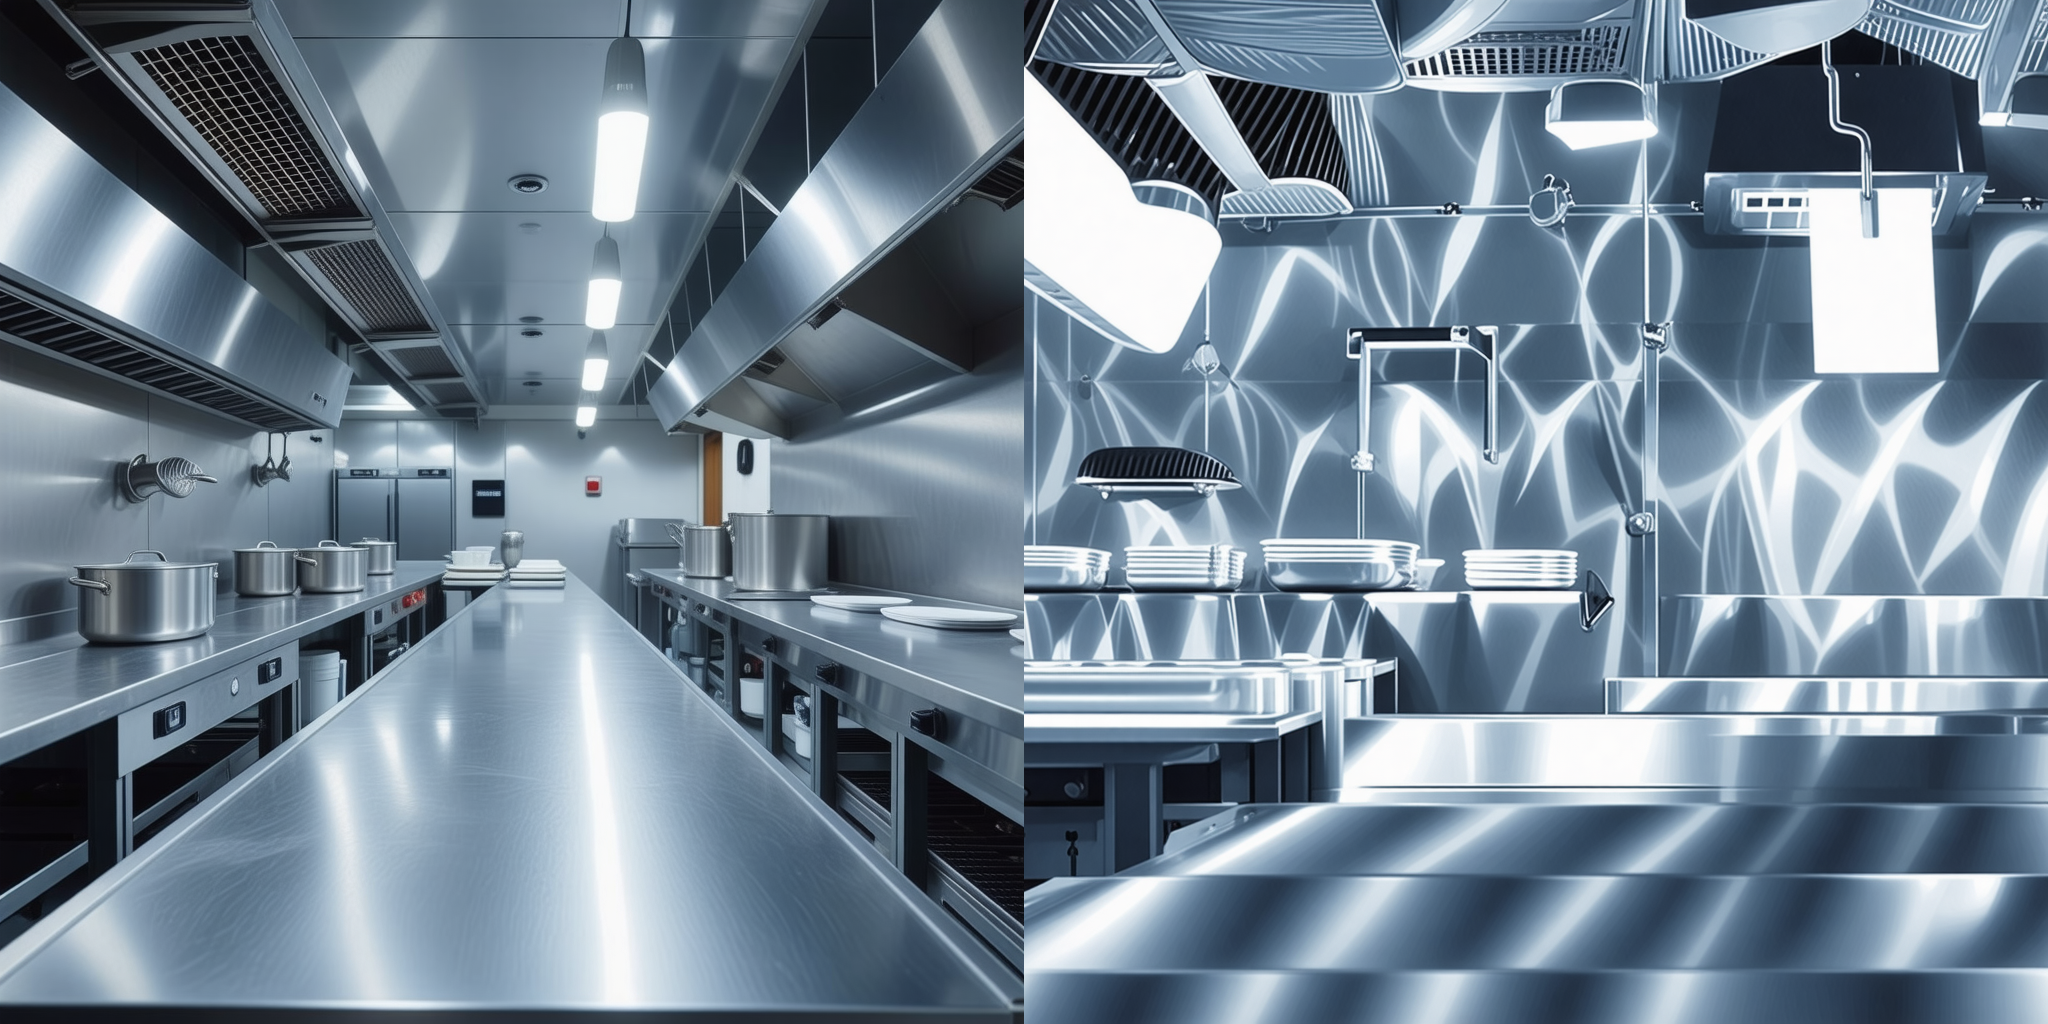

In [ ]:
hstack(show)

In [ ]:
idx

[1, 0]

In [ ]:
# seem to work on SD3.5, not funed good enough? plastic look outward push 
# todo: try improve SD3.5, try to move SD3.5 stuff to Flux, retry different parameeter

In [ ]:
# # Evaluate images
# image_paths = [angular_image, image_cfg]
# prompts = [prompt] * 2
# inferencer.reward(prompts, image_paths=image_paths)